In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 📊 Étape 4 : Visualisation Multidimensionnelle (Squelette Étudiant)

L'objectif est de concevoir des représentations visuelles premium pour identifier des tendances et insights clés.

### Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
# from src import data_clean as dc
# from src import utils_viz as uv

# Activation du style premium personnalisé (light ou dark)
# uv.set_custom_style(theme='light')
%matplotlib inline
print("Librairies de visualisation prêtes !")

Librairies de visualisation prêtes !


### Chargement du dataset enrichi

In [3]:
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')

df.head()

,Company,TypeName,Inches,Ram,OpSys,Weight,Price,Res_Width,Res_Height,Is_IPS,...,has_ssd,has_hdd,has_flash,has_hybrid,total_memory_gb,gpu_brand,has_intel_gpu,has_nvidia_gpu,has_amd_gpu,weight_kg
0,Apple,Ultrabook,13.3,8,macOS,1.37kg,71378.6832,2560,1600,1,...,1,0,0,0,128.0,Intel,1,0,0,1.37
1,Apple,Ultrabook,13.3,8,macOS,1.34kg,47895.5232,1440,900,0,...,0,0,1,0,128.0,Intel,1,0,0,1.34
2,HP,Notebook,15.6,8,No OS,1.86kg,30636.0000,1920,1080,0,...,1,0,0,0,256.0,Intel,1,0,0,1.86
3,Apple,Ultrabook,15.4,16,macOS,1.83kg,135195.3360,2880,1800,1,...,1,0,0,0,512.0,AMD,0,0,1,1.83
4,Apple,Ultrabook,13.3,8,macOS,1.37kg,96095.8080,2560,1600,1,...,1,0,0,0,256.0,Intel,1,0,0,1.37


### Tracés et analyses graphiques

#### Distribution des prix

['Company', 'TypeName', 'Inches', 'Ram', 'OpSys', 'Weight', 'Price', 'Res_Width', 'Res_Height', 'Is_IPS', 'Cpu_Gamme', 'Cpu_Frequence_GHz', 'has_ssd', 'has_hdd', 'has_flash', 'has_hybrid', 'total_memory_gb', 'gpu_brand', 'has_intel_gpu', 'has_nvidia_gpu', 'has_amd_gpu', 'weight_kg']


,Company,TypeName,Inches,Ram,OpSys,Weight,Price,Res_Width,Res_Height,Is_IPS,...,has_ssd,has_hdd,has_flash,has_hybrid,total_memory_gb,gpu_brand,has_intel_gpu,has_nvidia_gpu,has_amd_gpu,weight_kg
0,Apple,Ultrabook,13.3,8,macOS,1.37kg,71378.6832,2560,1600,1,...,1,0,0,0,128.0,Intel,1,0,0,1.37
1,Apple,Ultrabook,13.3,8,macOS,1.34kg,47895.5232,1440,900,0,...,0,0,1,0,128.0,Intel,1,0,0,1.34
2,HP,Notebook,15.6,8,No OS,1.86kg,30636.0000,1920,1080,0,...,1,0,0,0,256.0,Intel,1,0,0,1.86
3,Apple,Ultrabook,15.4,16,macOS,1.83kg,135195.3360,2880,1800,1,...,1,0,0,0,512.0,AMD,0,0,1,1.83
4,Apple,Ultrabook,13.3,8,macOS,1.37kg,96095.8080,2560,1600,1,...,1,0,0,0,256.0,Intel,1,0,0,1.37


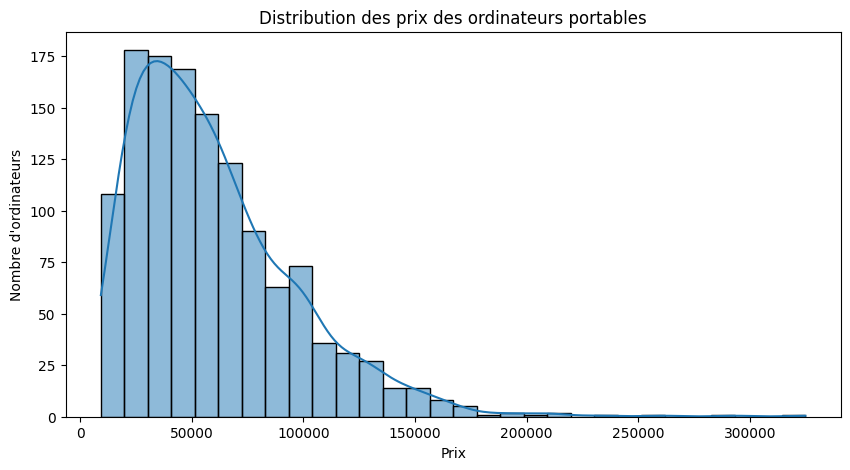

In [4]:
# vérification des colonnes
print(df.columns.tolist())
display(df.head())

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="Price", bins=30, kde=True)

plt.title("Distribution des prix des ordinateurs portables")
plt.xlabel("Prix")
plt.ylabel("Nombre d'ordinateurs")

plt.show()

**Explication du code**

Ce graphique permet d’analyser la distribution de la variable `Price`, qui correspond au prix des ordinateurs portables présents dans le jeu de données.

La fonction `sns.histplot()` est utilisée pour représenter la répartition des prix sous forme d’histogramme. L’argument `bins=30` permet de découper les prix en plusieurs intervalles afin d’observer dans quelles tranches de prix les ordinateurs sont les plus nombreux. L’option `kde=True` ajoute une courbe de densité, qui permet de mieux visualiser la tendance générale de la distribution.

L’histogramme a été choisi car la variable `Price` est une variable numérique continue. Ce type de graphique est adapté pour observer la forme d’une distribution, repérer les valeurs les plus fréquentes et identifier d’éventuelles valeurs extrêmes.

**Analyse de la distribution des prix** [ ] plus court

Le graphique montre que les prix des ordinateurs portables ne sont pas répartis de manière uniforme. La majorité des ordinateurs semble se situer dans une tranche de prix basse à moyenne, tandis que quelques modèles présentent des prix beaucoup plus élevés.

Cette forme de distribution indique une asymétrie : il existe probablement une concentration importante de modèles accessibles ou intermédiaires, accompagnée de quelques ordinateurs haut de gamme dont le prix est nettement supérieur.

Ces valeurs élevées peuvent correspondre à des machines premium, gaming ou professionnelles, équipées de composants plus performants comme un meilleur processeur, une carte graphique dédiée, davantage de mémoire vive ou un écran de meilleure résolution.

Cette analyse est importante car `Price` est la variable cible du projet. Comprendre sa distribution permet de mieux anticiper les difficultés possibles lors de la modélisation prédictive, notamment si certaines valeurs extrêmes influencent fortement les résultats.

**Conclusion**

La distribution des prix montre que le dataset contient principalement des ordinateurs situés dans des gammes de prix basses à moyennes, avec quelques modèles beaucoup plus chers. Cette observation justifie l’importance d’étudier les caractéristiques techniques associées aux prix élevés afin de mieux comprendre les facteurs qui influencent le coût d’un ordinateur portable.

#### Répartition des marques

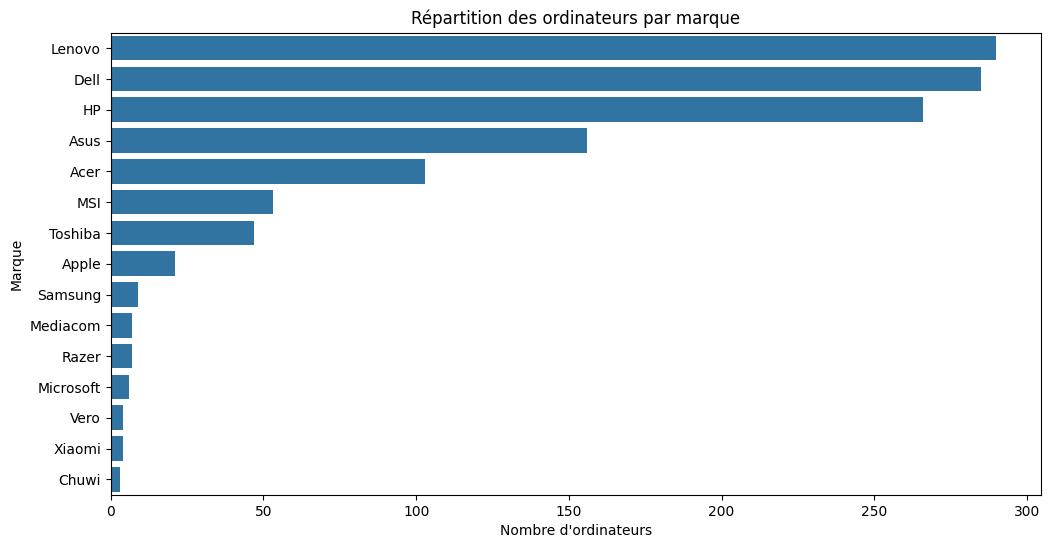

In [5]:
plt.figure(figsize=(12, 6))

company_counts = df["Company"].value_counts().head(15)

sns.barplot(
    x=company_counts.values,
    y=company_counts.index
)

plt.title("Répartition des ordinateurs par marque")
plt.xlabel("Nombre d'ordinateurs")
plt.ylabel("Marque")

plt.show()

**Explication du code**

Ce graphique permet d’étudier la répartition des ordinateurs portables selon leur marque, représentée par la variable `Company`.

La fonction `value_counts()` est utilisée pour compter le nombre d’ordinateurs associés à chaque marque. Ensuite, `.head(15)` permet de conserver uniquement les 15 marques les plus représentées dans le jeu de données. Ces résultats sont ensuite affichés sous forme de barplot horizontal avec `sns.barplot()`.

Le barplot a été choisi car `Company` est une variable catégorielle. Ce type de graphique est adapté pour comparer facilement les effectifs de plusieurs catégories. L’affichage horizontal permet aussi de rendre les noms des marques plus lisibles.

**Analyse de la répartition des marques**

Le graphique montre que certaines marques sont beaucoup plus représentées que les autres dans le dataset. Les marques **Lenovo**, **Dell** et **HP** dominent largement le jeu de données, avec un nombre d’ordinateurs nettement supérieur aux autres marques.

D’autres marques comme **Asus**, **Acer**, **MSI**, **Toshiba** ou **Apple** sont également présentes, mais en quantité plus faible. Enfin, certaines marques comme **Samsung**, **Mediacom**, **Razer**, **Microsoft**, **Vero**, **Xiaomi** ou **Chuwi** apparaissent avec très peu d’observations.

Cette répartition montre que le dataset est déséquilibré au niveau des marques. Cela signifie que les analyses globales peuvent être davantage influencées par les marques les plus représentées, notamment Lenovo, Dell et HP.

Il faudra donc être prudent lors de l’interprétation des résultats concernant les marques peu présentes. Par exemple, une marque avec peu d’ordinateurs peut avoir un prix moyen très élevé ou très faible, sans que cela soit forcément représentatif de l’ensemble de ses produits.

**Conclusion**

La répartition des marques montre une forte domination de quelques fabricants, en particulier Lenovo, Dell et HP. Cette information est importante pour la suite de l’analyse, car le déséquilibre entre les marques peut influencer les résultats statistiques et les modèles prédictifs.

#### Répartition des types d'ordinateurs


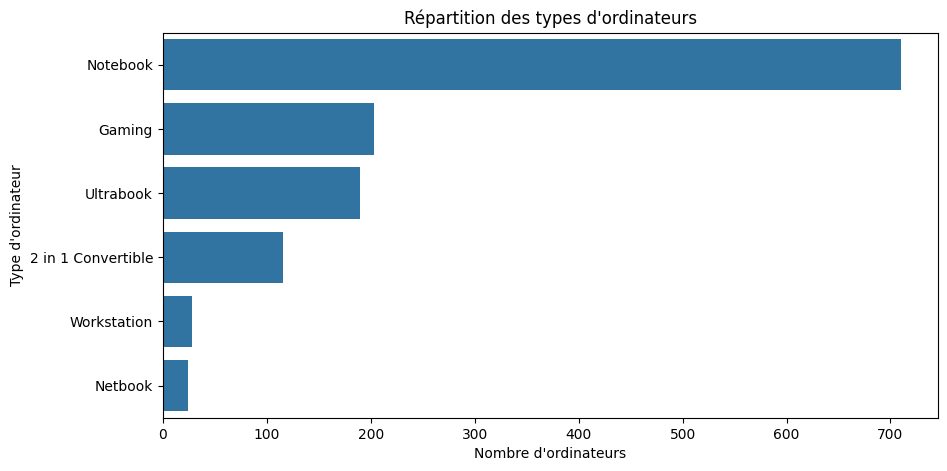

In [6]:
type_counts = df["TypeName"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=type_counts.values,
    y=type_counts.index
)

plt.title("Répartition des types d'ordinateurs")
plt.xlabel("Nombre d'ordinateurs")
plt.ylabel("Type d'ordinateur")

plt.show()

**Explication du code**

Ce graphique permet d’analyser la répartition des ordinateurs portables selon leur type, représenté par la variable `TypeName`.

La fonction `value_counts()` est utilisée pour compter le nombre d’ordinateurs dans chaque catégorie. Les résultats sont ensuite représentés avec un barplot horizontal grâce à `sns.barplot()`.

Le barplot a été choisi car `TypeName` est une variable catégorielle. Il permet de comparer clairement les effectifs entre les différentes catégories d’ordinateurs, comme les notebooks, les ultrabooks, les ordinateurs gaming ou les stations de travail.

**Analyse de la répartition des types d’ordinateurs**

Le graphique montre que la catégorie **Notebook** est très largement majoritaire dans le dataset. Cela signifie que la plupart des ordinateurs portables étudiés sont des modèles classiques destinés à un usage général.

Les catégories **Gaming** et **Ultrabook** sont également présentes, mais en quantité beaucoup plus faible. Les ordinateurs de type **2 in 1 Convertible**, **Workstation** et **Netbook** sont encore moins représentés.

Cette répartition est importante car le type d’ordinateur peut avoir une influence directe sur le prix. Par exemple, les ordinateurs gaming ou les stations de travail sont souvent équipés de composants plus performants, ce qui peut expliquer des prix plus élevés. À l’inverse, les notebooks classiques peuvent appartenir à des gammes de prix plus variées.

Cependant, le fort déséquilibre entre les catégories doit être pris en compte. Comme les notebooks sont très majoritaires, ils risquent d’avoir une influence importante sur les analyses globales et sur un éventuel modèle prédictif.

**Conclusion**

La répartition des types d’ordinateurs met en évidence une forte domination des notebooks dans le jeu de données. Cette variable reste néanmoins importante, car le type de machine peut expliquer certaines différences de prix. Les catégories peu représentées devront être analysées avec prudence afin d’éviter des conclusions trop générales.

#### Prix moyen par marque


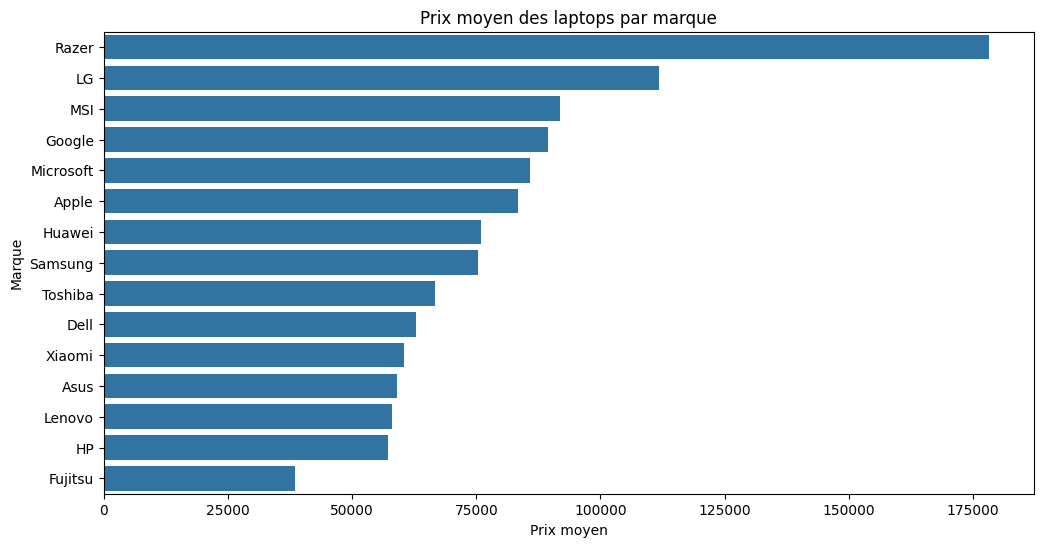

In [7]:
price_by_company = (
    df.groupby("Company")["Price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=price_by_company.values, y=price_by_company.index)

plt.title("Prix moyen des laptops par marque")
plt.xlabel("Prix moyen")
plt.ylabel("Marque")

plt.show()

**Explication du code**

Ce graphique permet d’analyser le prix moyen des ordinateurs portables selon leur marque.

Dans un premier temps, les données sont regroupées par marque avec `groupby("Company")`. Ensuite, la moyenne de la colonne `Price` est calculée pour chaque marque avec `.mean()`. Les résultats sont triés dans l’ordre décroissant grâce à `.sort_values(ascending=False)`, puis seules les 15 marques ayant le prix moyen le plus élevé sont conservées avec `.head(15)`.

Le barplot a été choisi car la variable `Company` est une variable catégorielle. Ce type de graphique est adapté pour comparer une valeur numérique moyenne, ici le prix moyen, entre plusieurs catégories. Il permet donc d’identifier rapidement les marques dont les ordinateurs sont en moyenne les plus chers dans le dataset.

**Analyse du prix moyen par marque**

Le graphique montre que certaines marques ont un prix moyen nettement plus élevé que les autres. La marque **Razer** arrive largement en tête, avec un prix moyen très supérieur aux autres marques. Cela peut s’expliquer par son positionnement sur des ordinateurs gaming haut de gamme, souvent équipés de composants performants.

Les marques **LG**, **MSI**, **Google**, **Microsoft** et **Apple** présentent également des prix moyens élevés. Ces marques sont souvent associées à des produits premium, professionnels ou spécialisés, ce qui peut expliquer un prix moyen plus important.

À l’inverse, des marques comme **Fujitsu**, **HP**, **Lenovo**, **Asus** ou **Xiaomi** ont un prix moyen plus faible dans ce classement. Cela ne signifie pas forcément que ces marques sont moins performantes, mais plutôt qu’elles proposent probablement une gamme plus large de modèles, incluant des ordinateurs plus accessibles.

Cette analyse est intéressante car elle montre que la marque peut avoir une influence sur le prix d’un ordinateur portable. Cependant, cette interprétation doit être nuancée : certaines marques peuvent être peu représentées dans le dataset. Si une marque possède seulement quelques modèles, son prix moyen peut être fortement influencé par un petit nombre d’ordinateurs très chers ou très peu chers.

Il sera donc utile de comparer cette analyse avec la répartition des marques observée précédemment, afin de vérifier si les marques ayant un prix moyen élevé sont suffisamment représentées dans le jeu de données.

**Conclusion**

Cette visualisation met en évidence des différences importantes de prix moyen selon les marques. Elle suggère que la marque peut être une variable explicative intéressante pour comprendre le prix des ordinateurs portables. Toutefois, les résultats doivent être interprétés avec prudence, notamment pour les marques peu représentées, car leur moyenne peut être moins fiable.

#### Relation poids / prix

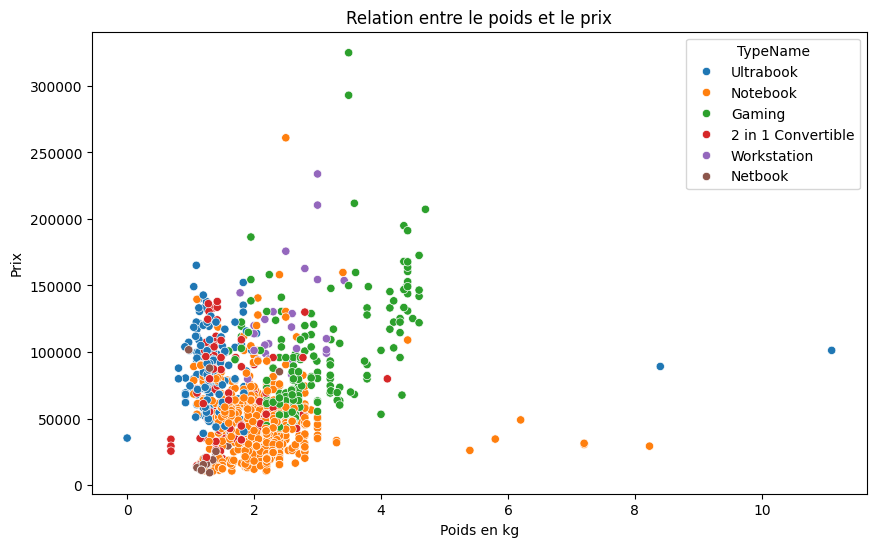

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="weight_kg", y="Price", hue="TypeName")
plt.title("Relation entre le poids et le prix")
plt.xlabel("Poids en kg")
plt.ylabel("Prix")
plt.show()

**Explication du code**

Ce graphique permet d’analyser la relation entre le poids d’un ordinateur portable et son prix.

La fonction `sns.scatterplot()` est utilisée pour afficher chaque ordinateur sous forme de point. L’axe horizontal représente le poids de l’ordinateur avec la variable `weight_kg`, tandis que l’axe vertical représente son prix avec la variable `Price`.

L’argument `hue="TypeName"` permet de colorer les points selon le type d’ordinateur : Notebook, Gaming, Ultrabook, Workstation, etc. Cela permet d’observer si certains types d’ordinateurs se distinguent dans la relation entre le poids et le prix.

Le nuage de points a été choisi car les deux variables étudiées, `weight_kg` et `Price`, sont numériques. Ce type de graphique est adapté pour visualiser une relation entre deux variables quantitatives et repérer d’éventuelles tendances, concentrations ou valeurs extrêmes.

**Analyse de la relation entre le poids et le prix**

Le graphique montre que la majorité des ordinateurs portables se situe entre environ 1 kg et 3 kg. Dans cette zone, les prix sont très dispersés : certains ordinateurs légers sont peu chers, tandis que d’autres atteignent des prix beaucoup plus élevés.

On observe que les ordinateurs de type **Gaming** sont souvent plus lourds et ont tendance à être plus chers. Cela peut s’expliquer par la présence de composants plus performants, comme une carte graphique dédiée, un système de refroidissement plus important ou une meilleure configuration matérielle.

Les **Ultrabooks**, au contraire, semblent généralement plus légers. Certains peuvent tout de même avoir un prix élevé, ce qui montre que le prix ne dépend pas uniquement du poids, mais aussi du positionnement premium, de la qualité de l’écran, du processeur ou du stockage.

On remarque également quelques valeurs extrêmes, avec des ordinateurs très lourds, au-delà de 6 kg, ou des prix très élevés. Ces points doivent être interprétés avec prudence, car ils peuvent correspondre à des machines spécifiques, à des erreurs dans les données ou à des modèles particuliers.

Globalement, la relation entre le poids et le prix ne semble pas parfaitement linéaire. Un ordinateur plus lourd n’est pas automatiquement plus cher, mais certains types de machines, notamment les ordinateurs gaming ou les stations de travail, peuvent être à la fois plus lourds et plus coûteux.

**Conclusion**

Cette visualisation montre que le poids seul n’explique pas entièrement le prix d’un ordinateur portable. Cependant, il peut donner des indications sur le type de machine : les ordinateurs gaming ou professionnels sont souvent plus lourds et plus chers, tandis que les ultrabooks sont généralement plus légers mais peuvent aussi atteindre des prix élevés. Le poids doit donc être analysé avec d’autres variables techniques pour mieux comprendre son influence sur le prix.

#### Relation stockage / prix

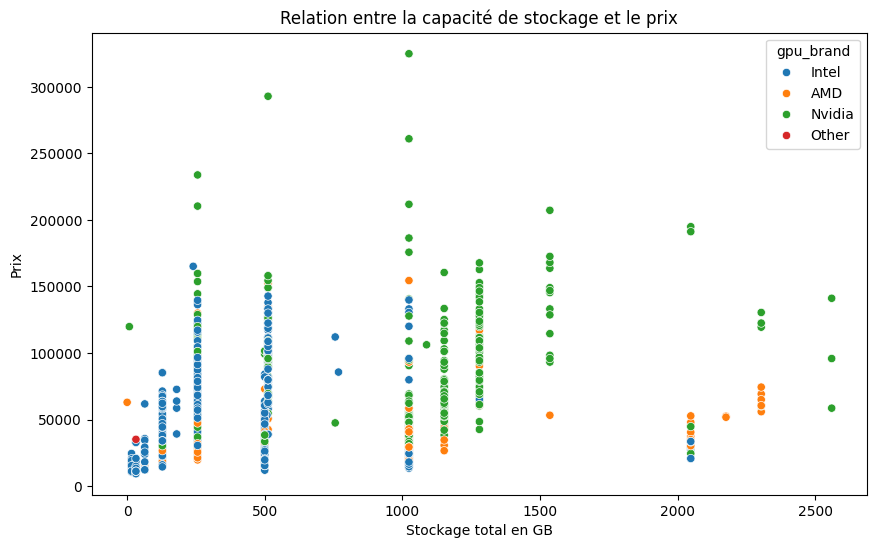

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="total_memory_gb", y="Price", hue="gpu_brand")

plt.title("Relation entre la capacité de stockage et le prix")
plt.xlabel("Stockage total en GB")
plt.ylabel("Prix")

plt.show()

**Explication du code**

Ce graphique permet d’analyser la relation entre la capacité totale de stockage d’un ordinateur portable et son prix.

La fonction `sns.scatterplot()` est utilisée pour représenter chaque ordinateur sous forme de point. L’axe horizontal correspond à la capacité totale de stockage, avec la variable `total_memory_gb`, tandis que l’axe vertical représente le prix avec la variable `Price`.

L’argument `hue="gpu_brand"` permet de colorer les points selon la marque du GPU : Intel, AMD, Nvidia ou Other. Cela permet d’observer si certains types de cartes graphiques sont associés à des prix plus élevés ou à des configurations de stockage plus importantes.

Le nuage de points a été choisi car les deux variables étudiées, `total_memory_gb` et `Price`, sont numériques. Ce type de graphique est adapté pour visualiser une éventuelle relation entre deux variables quantitatives et repérer des tendances, des concentrations ou des valeurs extrêmes.

**Analyse de la relation entre le stockage et le prix**

Le graphique montre que les ordinateurs portables sont principalement regroupés autour de certaines capacités de stockage, comme environ 256 Go, 512 Go, 1 To ou 2 To. Cela est logique, car les capacités de stockage sont généralement proposées sous forme de standards commerciaux.

On observe que les prix sont assez dispersés pour une même capacité de stockage. Par exemple, plusieurs ordinateurs avec 512 Go ou 1 To de stockage peuvent avoir des prix très différents. Cela montre que le stockage seul ne suffit pas à expliquer le prix d’un ordinateur portable.

Les ordinateurs équipés d’un GPU Nvidia semblent souvent associés à des prix plus élevés. Cela peut s’expliquer par le fait que les cartes graphiques Nvidia sont fréquentes dans les ordinateurs gaming ou professionnels, qui disposent souvent de composants plus performants et donc d’un prix plus important.

On remarque également quelques valeurs extrêmes, avec des prix très élevés pour certains ordinateurs ayant entre 1 To et 2 To de stockage. Ces modèles peuvent correspondre à des machines haut de gamme, mais ils doivent être analysés avec prudence afin de vérifier qu’il ne s’agit pas d’erreurs ou de valeurs atypiques.

Globalement, la capacité de stockage semble avoir une influence limitée si elle est observée seule. Le prix dépend probablement davantage d’une combinaison de facteurs : type de stockage, présence d’un SSD, processeur, mémoire vive, carte graphique, résolution de l’écran et marque.

**Conclusion**

Cette visualisation montre que la capacité totale de stockage n’explique pas à elle seule le prix d’un ordinateur portable. Même si les modèles avec de grandes capacités peuvent parfois être plus chers, les prix restent très variables pour une même quantité de stockage. Il sera donc nécessaire d’analyser le stockage avec d’autres caractéristiques techniques, notamment le type de stockage et la carte graphique, pour mieux comprendre son influence sur le prix.

#### Matrice de corrélation

Price                float64
Inches               float64
Res_Width              int64
Res_Height             int64
Cpu_Frequence_GHz    float64
total_memory_gb      float64
weight_kg            float64
has_ssd                int64
has_hdd                int64
has_flash              int64
has_hybrid             int64
has_intel_gpu          int64
has_nvidia_gpu         int64
has_amd_gpu            int64
dtype: object

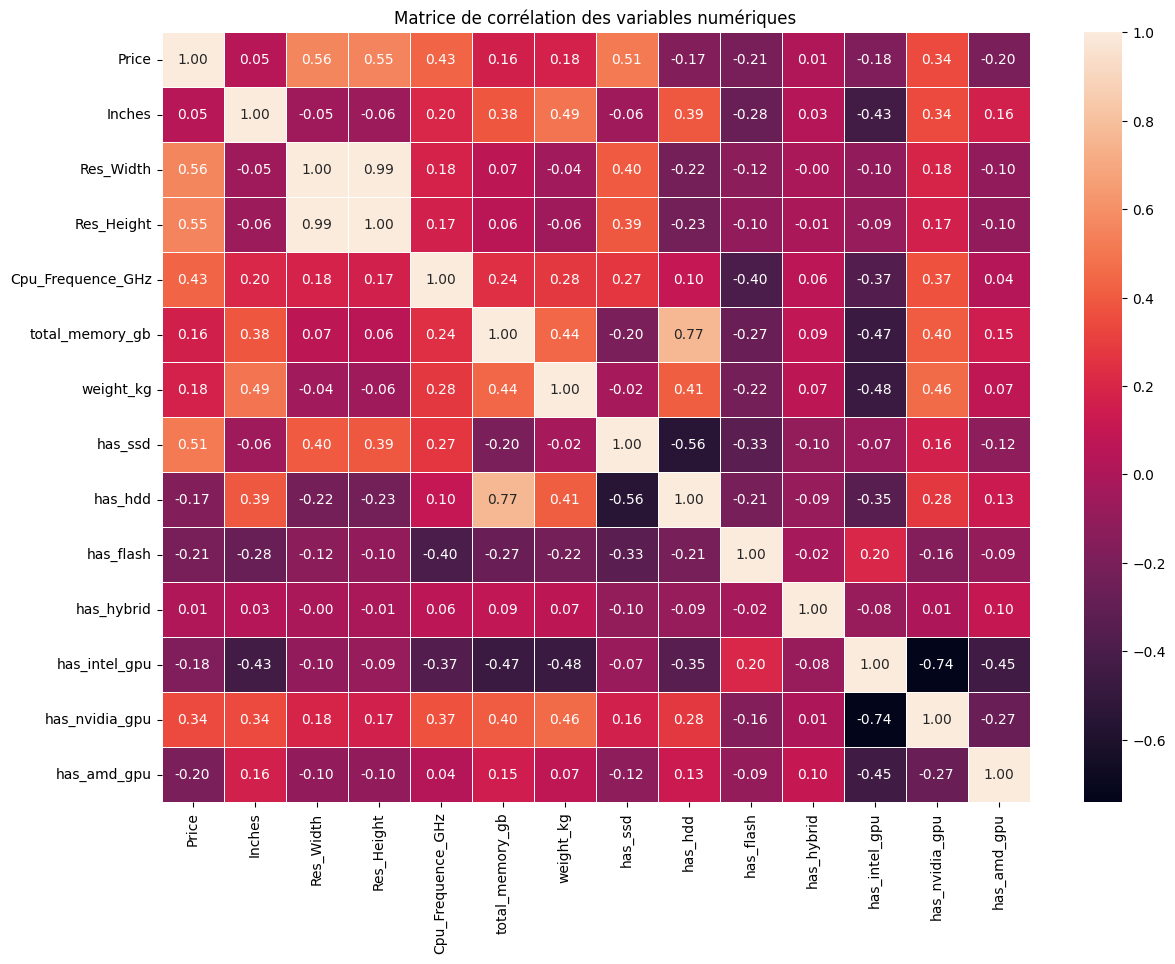

In [10]:
selected_numeric_columns = [
    "Price",
    "Inches",
    "Res_Width",
    "Res_Height",
    "Cpu_Frequence_GHz",
    "total_memory_gb",
    "weight_kg",
    "has_ssd",
    "has_hdd",
    "has_flash",
    "has_hybrid",
    "has_intel_gpu",
    "has_nvidia_gpu",
    "has_amd_gpu"
]

numeric_df = df[selected_numeric_columns].copy()

# Conversion sécurisée en numérique
# for col in selected_numeric_columns:
#     numeric_df[col] = pd.to_numeric(numeric_df[col], errors="coerce")

# print("Valeurs manquantes après conversion numérique :")
# display(numeric_df.isnull().sum())

# Vérification rapide des types
display(numeric_df.dtypes)

# Matrice de corrélation
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables numériques")
plt.show()

**Explication du code**

Pour étudier les relations entre les variables numériques du dataset, une matrice de corrélation a été calculée.  
Dans un premier temps, seules les colonnes numériques pertinentes ont été sélectionnées : le prix, la taille de l’écran, la résolution, la fréquence du processeur, la mémoire, le poids, ainsi que plusieurs variables binaires indiquant la présence ou non de certains composants comme un SSD, un HDD ou une carte graphique dédiée.

Une conversion sécurisée en valeurs numériques est ensuite réalisée avec `pd.to_numeric(..., errors="coerce")`. Cette étape permet de transformer les valeurs non numériques en valeurs manquantes plutôt que de provoquer une erreur. Cela est utile car certaines colonnes peuvent contenir des caractères ou des valeurs mal formatées dans le dataset d’origine. Dans un second temps, les valeurs non numériques ont été nettoyées directement dans le wrangling, le code de conversion a été commenté. 

Le code affiche ensuite le nombre de valeurs manquantes après conversion afin de vérifier la qualité des données avant de calculer la corrélation. On remarque ici qu’une seule valeur manquante apparaît dans la colonne `Inches`, tandis que les autres colonnes sont correctement converties.

Enfin, la matrice de corrélation est calculée avec `.corr()`, puis affichée sous forme de heatmap. La heatmap permet de visualiser plus facilement les corrélations positives et négatives entre les variables. Les valeurs proches de 1 indiquent une forte corrélation positive, les valeurs proches de -1 indiquent une forte corrélation négative, et les valeurs proches de 0 indiquent une faible relation linéaire.

**Analyse de la matrice de corrélation**

La matrice de corrélation permet d’identifier les variables numériques les plus liées au prix des ordinateurs portables.

On observe que le prix (`Price`) est positivement corrélé avec la largeur et la hauteur de résolution de l’écran (`Res_Width` et `Res_Height`), avec des corrélations d’environ 0,56 et 0,55. Cela signifie que les ordinateurs ayant une meilleure résolution d’écran ont tendance à être plus chers. Cette relation est cohérente, car les écrans de meilleure qualité sont souvent présents sur des modèles plus haut de gamme.

La présence d’un SSD (`has_ssd`) est également corrélée positivement avec le prix, avec une corrélation d’environ 0,51. Cela indique que les ordinateurs équipés d’un SSD sont généralement plus chers que ceux qui n’en possèdent pas. Ce résultat est logique, car le SSD améliore les performances générales de la machine.

La fréquence du processeur (`Cpu_Frequence_GHz`) présente aussi une corrélation positive avec le prix, autour de 0,43. Cela suggère que les ordinateurs équipés de processeurs plus rapides ont tendance à coûter plus cher.

La présence d’une carte graphique Nvidia (`has_nvidia_gpu`) est aussi positivement corrélée au prix, avec une valeur d’environ 0,35. Cette relation peut s’expliquer par le fait que les cartes graphiques dédiées sont souvent présentes dans des ordinateurs gaming ou professionnels, généralement plus coûteux.

À l’inverse, certaines variables sont négativement corrélées avec le prix. Par exemple, la présence d’un stockage flash (`has_flash`) présente une corrélation négative d’environ -0,21 avec le prix. La présence d’un GPU AMD (`has_amd_gpu`) est également légèrement négativement corrélée au prix, avec une valeur d’environ -0,20. Ces résultats doivent être interprétés avec prudence, car une corrélation ne signifie pas forcément une relation de cause à effet.

On remarque aussi une très forte corrélation entre `Res_Width` et `Res_Height`, proche de 0,99. Cela est logique, car la largeur et la hauteur de résolution augmentent généralement ensemble. Pour la modélisation, il faudra faire attention à ce type de redondance entre variables, car deux variables très corrélées peuvent apporter une information similaire.

Enfin, la corrélation entre `Price` et `Inches` est très faible, autour de 0,04. Cela signifie que la taille de l’écran seule ne semble pas expliquer fortement le prix. Un ordinateur plus grand n’est donc pas forcément plus cher : d’autres caractéristiques comme la résolution, le processeur, le SSD ou la carte graphique semblent avoir davantage d’impact.

**Conclusion**

Cette matrice de corrélation montre que le prix semble surtout lié à des caractéristiques techniques comme la résolution de l’écran, la présence d’un SSD, la fréquence du processeur et la présence d’une carte graphique Nvidia. En revanche, certaines variables comme la taille de l’écran semblent avoir peu d’influence directe sur le prix. Ces observations permettront d’orienter les prochaines analyses et de sélectionner les variables les plus pertinentes pour une éventuelle modélisation prédictive.